In [1]:
pip install biopython #Installing biopython

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
#Import python and Biopython packages and modules
from Bio import SeqIO #Import Biopython package SeqIO
from Bio.Data import CodonTable #Import Biopython package CodonTable
from Bio import Seq #Import Biopython package Seq
from Bio.SeqUtils.ProtParam import ProteinAnalysis #Import ProteinAnalysis from ProtParam module
from Bio.SeqUtils import gc_fraction #Import GC from Bio.SeqUtils module
import pandas as pd #Import pandas package
import matplotlib.pyplot as plt #Import matplotlib.pyplot package
import seaborn as sns #Import seaborn package
import numpy as np #Import numpy package

In [ ]:
#Functions: 1. Document Dr. X's function with comments and with markdown text in your Jupyter notebook.

In [6]:
"""
Function Description:
Extracts sequences from a FASTA file and returns them in a dictionary.
Arguments:
fasta_fn (str): The file path of the FASTA file.
Return Type:
dict: A dictionary containing species names as keys and sequences as values.
    """
def get_sequences_from_file(fasta_fn):                         #Function takes a fasta file as arguement 
    sequence_data_dict = {}                                    #Define an empty dictionary for sequence data
    for record in SeqIO.parse(fasta_fn, "fasta"):              #For each FASTA record, use Biopython's SeqIO module
        description = record.description.split()               #Split the description line of the sequence into variables
        species_name = description[1] + " " + description[2]   #Create species name (genus + species) separated by a white space
        sequence_data_dict[species_name] = record.seq          #Append the empty dictionary with the species name and sequences from previous step
    return sequence_data_dict                                  #Return a dictionary with species as key and corresponding sequences as value

#Testing function
fasta_fn = "penguins_cytb.fasta"
get_sequences_from_file(fasta_fn)

{'Aptenodytes forsteri': Seq('ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTAATAACTCC...TAA'),
 'Aptenodytes patagonicus': Seq('ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTAATAACTCC...TAA'),
 'Eudyptes chrysocome': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptes chrysolophus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptes sclateri': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptula minor': Seq('ATGGCCCCCAACCTCCGAAAATCTCACCCCCTCCTAAAAATAATCAACAACTCT...TAA'),
 'Pygoscelis adeliae': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATTAACAACTCC...TAA'),
 'Pygoscelis antarctica': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATCAACAACTCC...TAG'),
 'Pygoscelis papua': Seq('ATGGCCCCCAACCTTCGAAAATCCCACCCTCTCCTAAAAATAATCAACAAATCC...TAG'),
 'Spheniscus demersus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAACAATCAACAACTCC...TAA'),
 'Spheniscus humboldti': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAAC

In [ ]:
#Functions: 2. Write a function that translates a string of nucleotides to amino acids based on Dr. X's pseudo-code suggestion

In [7]:
"""
    Function Description:
    Translates a nucleotide sequence into an amino acid sequence.

    Args:
    - string_nucleotides (str): A string representing the nucleotide sequence.

    Returns:
    - str: A string representing the translated amino acid sequence.
    """

def translate_function(string_nucleotides):                   #Function takes nucleotide as strings
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]   #Loading Biopython's codon table for vertebrate's mitochondira
    print(mito_table)
    aa_seq_string = ""                                        #Create an empty string for the aa sequence
    for i in range(0, len(string_nucleotides), 3):            #Loops through every 3rd position in string_nucleotides to return a codon. Range stars from the start of sequence to the end.
        codon = string_nucleotides[i:i+3]                     #Codon equals to multiple of three
        if codon in mito_table.forward_table:                 #Checking condition if codon is in the codon table 
            amino_acid = mito_table.forward_table[codon]      #Matches the codon from codon table and save it to the string amino_acid    
            if amino_acid == '*':                             #Check for stop codon    
                break                                         #Break the loop after encountering stop codon. 
            aa_seq_string += amino_acid                       #Append the translated amino acids to aa_seq_string
        else:
            break                                             #Stop translation if encountering an unknown codon
    
    return aa_seq_string                                      #Return the translated amino acid sequence

# Test the function
string_nucleotide = 'ATACGTAGCTGGCCAAGGCCTTAAGGTGAAAT'
translated_sequence = translate_function(string_nucleotide)
print("Translated sequence:", translated_sequence)

Table 2 Vertebrate Mitochondrial, SGC1

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA W   | A
T | TTG L   | TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L   | CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I(s)| ACT T   | AAT N   | AGT S   | T
A | ATC I(s)| ACC T   | AAC N   | AGC S   | C
A | ATA M(s)| ACA T   | AAA K   | AGA Stop| A
A | ATG M(s)| ACG T   | AAG K   | AGG Stop| G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V(s)| GCG A   | GAG E   | GGG G   

In [ ]:
#Functions: 3. Alternate function for amino acid translation

In [8]:
from Bio.Seq import Seq

"""
    Function Description:
    Translates a nucleotide sequence into an amino acid sequence using Biopython's Seq.translate function.

    Args:
    - string_nucleotides (str): A string representing the nucleotide sequence.

    Returns:
    - str: A string representing the translated amino acid sequence.
    """

def translate_alternative(string_nucleotides):   #Alternartive function takes strings of nucleotide as arguement 
    nucleotide_seq = Seq(string_nucleotides)     #Convert nucleotide strings to sequence
    amino_acids = nucleotide_seq.translate(table="Vertebrate Mitochondrial", to_stop=True) #Biopython's Seq.translate performs translation referring codon table till the first encounter of a stop codon
    return str(amino_acids)                      #Returning translated amino acids                   

# Test the function
string_nucleotide = 'ATACGTAGCTGGCCAAGGCCTTAAGGTGAAATA'
translated_sequence = translate_alternative(string_nucleotide)
print("Translated sequence:", translated_sequence)

Translated sequence: MRSWP


In [ ]:
#Functions: 4.  Write a function that calculates the molecular weight of each amino acid sequence.

In [9]:
"""
    Function Description:
    Computes the molecular weight of an amino acid sequence.

    Args:
    - aa_seq (str): A string representing the amino acid sequence.

    Returns:
    - float: The molecular weight of the amino acid sequence.
    """
def compute_molecular_weight(aa_seq):                    #Defining a function which takes a string a amino acids as an arguement
    analysed_seq = ProteinAnalysis(aa_seq)               #Convert string of amino acids to a sequence object using ProteinAnalysis
    molecular_weight = analysed_seq.molecular_weight()   #Calculating molecular weight of amino acid sequence
    
    return molecular_weight                              #Return the molecular weight

#Test the function 
aa_seq = 'PAYVAQLSEW'
compute_molecular_weight(aa_seq)

1163.2785000000001

In [ ]:
#Functions: 5. GC Content Analysis

In [10]:
"""
    Computes the GC content of a DNA sequence.

    Args:
    - dna_seq (str): A string representing the DNA sequence.

    Returns:
    - float: The GC content of the DNA sequence as a percentage.
    """
def gc_content(dna_seq):                           #Defining a function which takes a string of DNA sequence as an arguement
    count_g = dna_seq.count('G')                   #Counting the number of 'G'
    count_c = dna_seq.count('C')                   #Counting the number of 'C'
    countGC = count_g + count_c                    #Summing up the counts of 'G' and 'C'
    dna_len = len(dna_seq)                         #Calculating the length of DNA sequence
    gc_p = countGC/dna_len * 100                   #GC content calculation
    return gc_p                                    #Returning the GC content

#Test the function
dna_seq = 'ATACGTAGCTGGCCAAGGCCTTAAGGTGAAAT'
gc_content(dna_seq)

46.875

In [11]:
#We have got the following code from Dr.X, which will help us to create a dataframe.

cytb_seqs = get_sequences_from_file("penguins_cytb.fasta")
print(cytb_seqs)

penguins_df = pd.read_csv("penguins_mass.csv") #Includes only data for body mass 
species_list = list(penguins_df.species)

{'Aptenodytes forsteri': Seq('ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTAATAACTCC...TAA'), 'Aptenodytes patagonicus': Seq('ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTAATAACTCC...TAA'), 'Eudyptes chrysocome': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'), 'Eudyptes chrysolophus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'), 'Eudyptes sclateri': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'), 'Eudyptula minor': Seq('ATGGCCCCCAACCTCCGAAAATCTCACCCCCTCCTAAAAATAATCAACAACTCT...TAA'), 'Pygoscelis adeliae': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATTAACAACTCC...TAA'), 'Pygoscelis antarctica': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATCAACAACTCC...TAG'), 'Pygoscelis papua': Seq('ATGGCCCCCAACCTTCGAAAATCCCACCCTCTCCTAAAAATAATCAACAAATCC...TAG'), 'Spheniscus demersus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAACAATCAACAACTCC...TAA'), 'Spheniscus humboldti': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAACAATCAACAAC

In [ ]:
#Functions: 6. Add two new columns to the penguin DataFrame: (1) molecular weight and (2) GC content.

# Setting the value to 'NaN' to indicate that these cells are currently empty.

In [12]:
penguins_df['molecular_weight'] = float('NaN') #Initializing new column molecular weight with NaN values
penguins_df['GC_content'] = float('NaN') #Initializing new column GC_content with NaN values

print(penguins_df.head()) #display the output

                   species   mass  molecular_weight  GC_content
0     Aptenodytes forsteri  28.00               NaN         NaN
1  Aptenodytes patagonicus  13.40               NaN         NaN
2      Eudyptes chrysocome   2.80               NaN         NaN
3    Eudyptes chrysolophus   4.50               NaN         NaN
4        Eudyptes sclateri   4.25               NaN         NaN


In [ ]:
#Functions: 7. A for-loop that translates each sequence and also gets molecular weight, as well as computes the GC content of each translated sequence and adds those data to DataFrame

In [13]:
for key, value in cytb_seqs.items():
    aa_seq = translate_alternative(value)                         # Translate using translation function from Step 3.
    molecular_weight = compute_molecular_weight(aa_seq)           # Calculate molecular weight
    GC_content = gc_content(value)                                # Calculate GC content

    # Update DataFrame with calculated values
    penguins_df.loc[penguins_df['species'] == key, 'molecular_weight'] = molecular_weight   #add MW to DataFrame
    penguins_df.loc[penguins_df['species'] == key, 'GC_content'] = GC_content               #add GC content to DataFrame             
    
print(penguins_df)

                    species   mass  molecular_weight  GC_content
0      Aptenodytes forsteri  28.00        42459.6021   48.381452
1   Aptenodytes patagonicus  13.40        42563.7067   49.693788
2       Eudyptes chrysocome   2.80        42475.5753   51.181102
3     Eudyptes chrysolophus   4.50        42445.5493   50.918635
4         Eudyptes sclateri   4.25        42475.5753   50.831146
5           Eudyptula minor   1.60        42491.6408   49.256343
6        Pygoscelis adeliae   4.60        42458.6140   49.081365
7     Pygoscelis antarctica   4.10        42404.5423   47.769029
8          Pygoscelis papua   6.10        42595.8759   47.156605
9       Spheniscus demersus   3.20        42431.5490   48.293963
10     Spheniscus humboldti   4.75        42399.5520   49.256343
11  Spheniscus magellanicus   3.40        42459.6021   48.206474


In [ ]:
#Functions: #8. Plot a bar-chart of the mass with the x-axes labeled with species names.

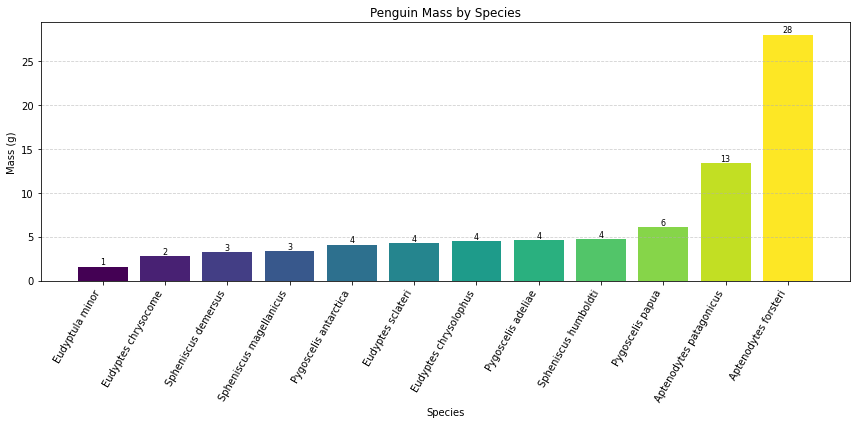

In [14]:
sorted_df = penguins_df.sort_values(by='mass')             #Sorting the DataFrame by mass in ascending order

colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_df))) #Use the viridis color palette

plt.figure(figsize=(12,6))                                 #Increase figure size for better readability

bars = plt.bar(sorted_df["species"], sorted_df["mass"], color=colors)

plt.xlabel('Species')
plt.ylabel('Mass (g)')
plt.title('Penguin Mass by Species')

plt.xticks(rotation=60, ha='right')            #Improved readability
plt.grid(axis='y', linestyle='--', alpha=0.6)  #Add grid for clarity

for bar in bars:                                                  
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8) #Add values on top of bars

plt.tight_layout()                                                   #Prevents label cutoff
plt.show()

In [ ]:
Q1. The smallest penguin species is "Eudyptula minor"
Q2. They are geographically distributed in the coastal waters of southern mainland Australia and Tasmania.

In [ ]:
#Functions: 9. Plot a visualization of the molecular weight (y-axis) as a function of GC-content (x-axis).

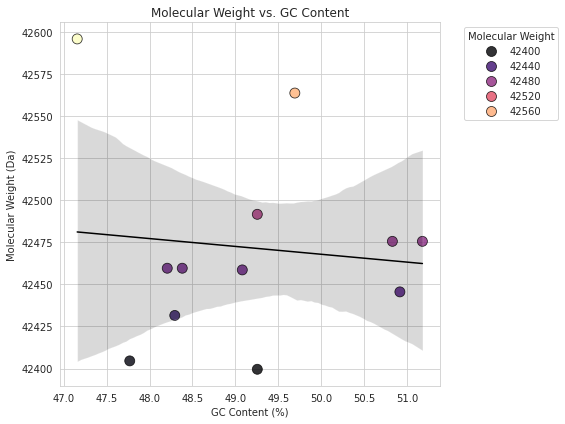

In [15]:
sns.set_style("whitegrid")  #Cleaner background
sns.set_palette("magma")    #Setting color palette

plt.figure(figsize=(8,6))   #Better sizing

sns.scatterplot(
    data=penguins_df,
    x='GC_content',
    y='molecular_weight',
    hue='molecular_weight', #Color by molecular weight
    palette='magma',
    s=100,                    
    edgecolor='black',        
    alpha=0.8                 
)

sns.regplot(                #Add regression line
    data=penguins_df,
    x='GC_content',
    y='molecular_weight',
    scatter=False,
    color='black',
    line_kws={"linewidth":1.5}
)

plt.xlabel('GC Content (%)')
plt.ylabel('Molecular Weight (Da)')
plt.title('Molecular Weight vs. GC Content')

plt.legend(title='Molecular Weight', bbox_to_anchor=(1.05, 1), loc='upper left')  #Move legend outside

plt.tight_layout()
plt.show()

In [ ]:
#Functions: 10. Save the new DataFrame to a file called "penguins_mass_cytb.csv"

In [16]:
penguins_df.to_csv('penguins_mass_cytb.csv', index=False) #Saving as a .csv file.

In [ ]:
#Functions: Bonus!

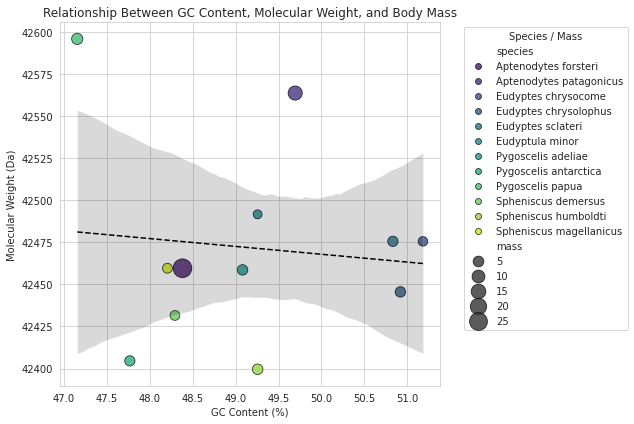

In [17]:
#Relationship between GC content, molecular weight, and body mass

sns.set_style("whitegrid")  

plt.figure(figsize=(9,6))   

sns.scatterplot(
    data=penguins_df,                    
    x="GC_content",                        #GC content on x-axis
    y="molecular_weight",                  #Molecular weight on y-axis
    size="mass",                           #Point size represents body mass
    hue="species",                         #Color represents species
    palette="viridis",                    
    sizes=(80, 350),                       
    alpha=0.8,                             
    edgecolor="black"                      
)

sns.regplot(                                
    data=penguins_df,                      
    x="GC_content",                        
    y="molecular_weight",                  
    scatter=False,                        
    color="black",                         
    line_kws={"linewidth":1.5, "linestyle":"--"} #Add regression line
)

plt.xlabel("GC Content (%)")              #Labeling x-axis with unit
plt.ylabel("Molecular Weight (Da)")       #Labeling y-axis with unit
plt.title("Relationship Between GC Content, Molecular Weight, and Body Mass")  #Plot title

plt.legend(
    title="Species / Mass",               #Title of legend
    bbox_to_anchor=(1.05, 1),            
    loc="upper left"
)

plt.tight_layout()                        
plt.show()                               

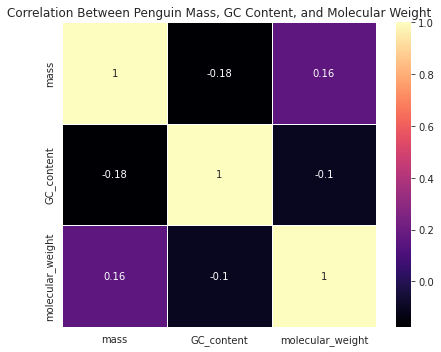

In [18]:
#Correlation heatmap of numerical variables 

numeric_df = penguins_df[["mass", "GC_content", "molecular_weight"]]  #Selecting only numerical columns for correlation analysis

correlation_matrix = numeric_df.corr()                                #Calculating correlation between selected variables

plt.figure(figsize=(6,5))  

sns.heatmap(
    correlation_matrix,     
    annot=True,             
    cmap="magma",           #Setting color palette
    linewidths=0.5         
)

plt.title("Correlation Between Penguin Mass, GC Content, and Molecular Weight")  #Adding title

plt.tight_layout()  
plt.show()          